<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/). 
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA). 
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Sun Mar 30 13:09:08 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   62C    P8             10W /   84W |     168MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

2.4.1+cu118


## 1. What are 3 areas in industry where computer vision is currently being used?

In [4]:
# 1. advance robotic surgery in healthcare
# 2. virtual mirrors in retail industry
# 3. camera-based customer analysis application

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find. 

In [5]:
# Overfitting means crating a model that matches the training set so closely 
# that the model fails to make correct predictions on new data.

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each. 
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

In [6]:
# 1. Early stopping: Early stopping pauses the training before the machine learns the noise in the data.
# 2. Pruning or feature selection: pruning identifies the most important features within the training set and eliminates irrelevant ones.
# 3. Regularization: Regularization trys to eliminate those factors that do not impact the pridiction outcomes by grading features based on importance.

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [7]:
# load the torchvision.datasets.MNIST() train and test datasets
import torchvision
from torchvision import datasets
from torchvision import transforms

data_root = "D:/VScodeProjects/pytorch-deep-learning/data"

train_data = datasets.MNIST(root=data_root,
                                   train=True,
                                   download=False,
                                   transform=transforms.ToTensor(),
                                   target_transform=None)

test_data = datasets.MNIST(root=data_root,
                                  train=False,
                                  download=False,
                                  transform=transforms.ToTensor())

In [8]:
train_data, test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: D:/VScodeProjects/pytorch-deep-learning/data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: D:/VScodeProjects/pytorch-deep-learning/data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 6. Visualize at least 5 different samples of the MNIST training dataset.

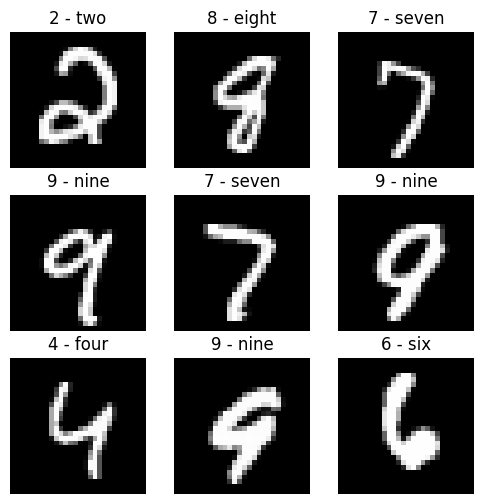

In [9]:
# visualize at least 5 different samples of the MNIST training dataset
import matplotlib.pyplot as plt
import numpy as np
class_names = train_data.classes
fig = plt.figure(figsize=(6, 6))
rows, cols = 3, 3
for i in range(1, 10):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    fig.add_subplot(rows, cols, i)
    plt.title(class_names[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [10]:
# create a DataLoader for the MNIST training dataset, set the batch_size = 32
from torch.utils.data import DataLoader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Dataloaders: {train_loader, test_loader}")
print(f"Length of train dataloader: {len(train_loader)}")
print(f"Length of test dataloader: {len(test_loader)}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001C9D24D11F0>, <torch.utils.data.dataloader.DataLoader object at 0x000001C9D24D1250>)
Length of train dataloader: 1875
Length of test dataloader: 313


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [4]:
# creat a CNN model
import torch.nn as nn
class FashionMNISTModel_1(nn.Module):
    """
    Model architecture coying TinyVGG
    """
    def __init__(self):
        super().__init__()
        # block_1: Conv2d + ReLU
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # block_2: Conv2d + ReLU + MaxPooling
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # block_3: Conv2d + ReLU
        self.block_3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # block_4: Conv2d + ReLU + MaxPooling
        self.block_4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.classifier(x)
        return x
    
torch.manual_seed(42)
model_3_1 = FashionMNISTModel_1().to(device)
model_3_1

FashionMNISTModel_1(
  (block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (block_4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [5]:
class FashionMNISTModel_2(nn.Module):
    """
    Model architecture coying TinyVGG
    """
    def __init__(self):
        super().__init__()
        # block_1: Conv2d + ReLU
        self.block_1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # block_2: Conv2d + ReLU + MaxPooling
        self.block_2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # block_3: Conv2d + ReLU
        self.block_3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # block_4: Conv2d + ReLU + MaxPooling
        self.block_4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        # classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 10)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.block_3(x)
        x = self.block_4(x)
        x = self.classifier(x)
        return x
    
torch.manual_seed(42)
model_3_2 = FashionMNISTModel_2().to(device)
model_3_2

FashionMNISTModel_2(
  (block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (block_4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=10, bias=True)
  )
)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [13]:
# Train the model for 5 epochs on CPU
import time
import torch.optim as optim
from tqdm import tqdm

model_cpu = model_3_1.to('cpu')

def accuracy_fn(y_true, y_pred):
    corret = torch.eq(y_true, y_pred).sum().item()
    acc = (corret / len(y_pred)) * 100
    return acc

# define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_3_1.parameters(), lr=0.1)

# define start time
start_time = time.time()
# define number of epochs
epochs = 5

# training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    ### Training
    train_loss = 0
    # loop through training batches
    for batch, (images, labels) in enumerate(train_loader):
        # model.train()
        model_3_1.train()
        # 1. Forward pass
        images, labels = images.to('cpu'), labels.to('cpu')
        model_3_1.to('cpu')
        y_pred = model_3_1(images)

        # 2. Calculate loss per batch
        loss = loss_fn(y_pred, labels)
        train_loss += loss

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Backward pass
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # print training statistics
        if batch % 400 == 0:
            print(f"Looked at {batch * len(images)}/{len(train_loader.dataset)} samples.")

    # calculate average loss
    train_loss /= len(train_loader)

    ### Testing
    test_loss, test_acc = 0, 0
    model_3_1.eval()
    with torch.inference_mode():
        for batch, (test_images, test_labels) in enumerate(test_loader):
            # Make sure test data on CPU
            test_images, test_labels = test_images.to('cpu'), test_labels.to('cpu')
            # 1. Forward pass
            label_pred = model_3_1(test_images)
            # 2. Calculate loss
            loss = loss_fn(label_pred, test_labels)
            test_loss += loss
            # 3. Calculate accuracy
            test_acc += accuracy_fn(y_true=test_labels, y_pred=torch.argmax(label_pred, dim=1))
        # calculate average loss and accuracy
        test_loss /= len(test_loader)
        test_acc /= len(test_loader)
    
    # print statistics
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

# calculate training time
end_time = time.time()
total_training_time_cpu = end_time - start_time
print(f"Total training time: {total_training_time_cpu:.2f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 20%|██        | 1/5 [01:49<07:16, 109.19s/it]


Train loss: 0.38854 | Test loss: 0.05804 | Test accuracy: 98.05%

Epoch: 1
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 40%|████      | 2/5 [03:23<05:01, 100.67s/it]

...


Train loss: 0.03074 | Test loss: 0.03961 | Test accuracy: 98.90%

Epoch: 3
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 80%|████████  | 4/5 [06:02<01:26, 86.33s/it]


Train loss: 0.02203 | Test loss: 0.02804 | Test accuracy: 99.15%

Epoch: 4
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 5/5 [07:34<00:00, 90.82s/it]


Train loss: 0.01652 | Test loss: 0.02640 | Test accuracy: 99.20%

Total training time: 454.11 seconds


The acc of the V1 model above is too low.
So try the V2 model.

In [14]:
import time
import torch.optim as optim
from tqdm import tqdm
# Train the model for 5 epochs on CPU
model_cpu = model_3_2.to(device)

def accuracy_fn(y_true, y_pred):
    corret = torch.eq(y_true, y_pred).sum().item()
    acc = (corret / len(y_pred)) * 100
    return acc

# define the loss function and the optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_3_2.parameters(), lr=0.1)

# define start time
start_time = time.time()
# define number of epochs
epochs = 5

# training and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n-----")
    ### Training
    train_loss = 0
    # loop through training batches
    for batch, (images, labels) in enumerate(train_loader):
        # model.train()
        model_3_2.train()
        # 1. Forward pass
        images, labels = images.to('cpu'), labels.to('cpu')
        model_3_2.to('cpu')
        y_pred = model_3_2(images)

        # 2. Calculate loss per batch
        loss = loss_fn(y_pred, labels)
        train_loss += loss

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Backward pass
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # print training statistics
        if batch % 400 == 0:
            print(f"Looked at {batch * len(images)}/{len(train_loader.dataset)} samples.")

    # calculate average loss
    train_loss /= len(train_loader)

    ### Testing
    test_loss, test_acc = 0, 0
    model_3_2.eval()
    with torch.inference_mode():
        for batch, (test_images, test_labels) in enumerate(test_loader):
            # Make sure test data on CPU
            test_images, test_labels = test_images.to('cpu'), test_labels.to('cpu')
            # 1. Forward pass
            label_pred = model_3_2(test_images)
            # 2. Calculate loss
            loss = loss_fn(label_pred, test_labels)
            test_loss += loss
            # 3. Calculate accuracy
            test_acc += accuracy_fn(y_true=test_labels, y_pred=torch.argmax(label_pred, dim=1))
        # calculate average loss and accuracy
        test_loss /= len(test_loader)
        test_acc /= len(test_loader)
    
    # print statistics
    print(f"\nTrain loss: {train_loss:.5f} | Test loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")

# calculate training time
end_time = time.time()
total_training_time_cpu = end_time - start_time
print(f"Total training time: {total_training_time_cpu:.2f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 20%|██        | 1/5 [01:09<04:38, 69.71s/it]


Train loss: 0.18030 | Test loss: 0.04586 | Test accuracy: 98.46%

Epoch: 1
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 40%|████      | 2/5 [02:19<03:29, 69.76s/it]

...


Train loss: 0.03327 | Test loss: 0.03817 | Test accuracy: 98.80%

Epoch: 3
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


 80%|████████  | 4/5 [04:48<01:12, 72.20s/it]


Train loss: 0.02440 | Test loss: 0.02515 | Test accuracy: 99.11%

Epoch: 4
-----
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.


100%|██████████| 5/5 [05:57<00:00, 71.54s/it]


Train loss: 0.01947 | Test loss: 0.02782 | Test accuracy: 99.16%

Total training time: 357.69 seconds


In [15]:
# store the state_dict of the V2 model
torch.save(model_3_2.state_dict(), "model_3_2.pth")

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

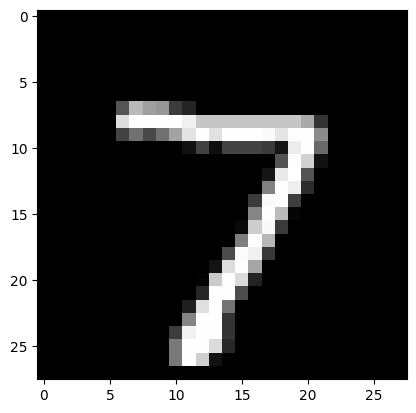

In [16]:
plt.imshow(test_data[0][0].squeeze(), cmap="gray")

C:\Users\asus\AppData\Local\Temp\ipykernel_29308\603999189.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_3_2.load_state_dict(torch.load("model_3_2.pth"))


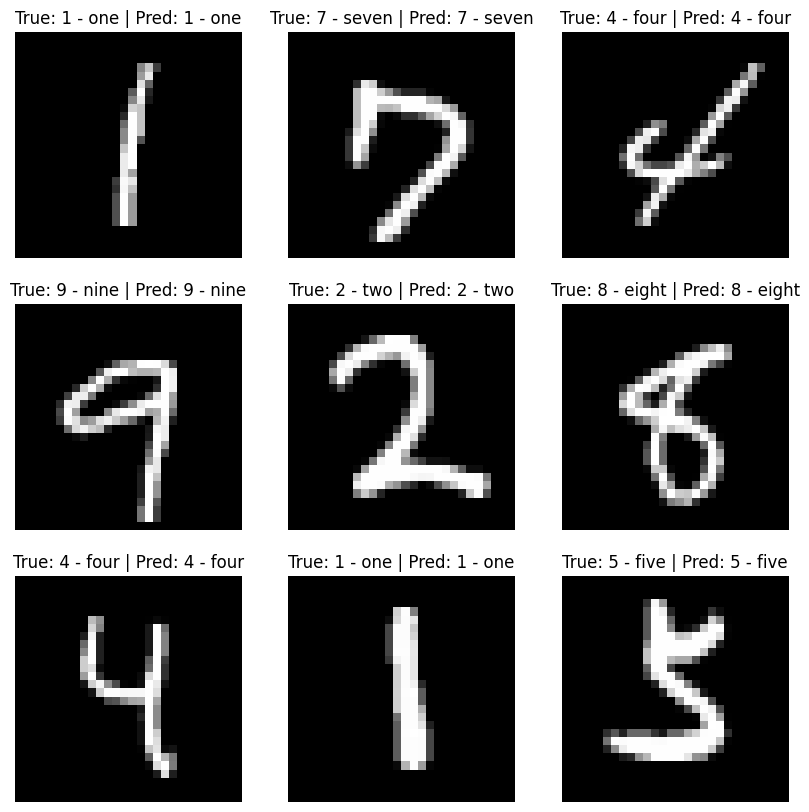

In [17]:
# load the model state_dict
torch.manual_seed(42)
model_3_2 = FashionMNISTModel_2()
model_3_2.load_state_dict(torch.load("model_3_2.pth"))
model_3_2.eval()
# plot 9 random test images
fig = plt.figure(figsize=(10, 10))
rows, cols = 3, 3
for i in range(1, 10):
    sample_idx = torch.randint(len(test_data), size=(1,)).item()
    img, label = test_data[sample_idx]
    # predict label using model
    with torch.no_grad():
        pred = model_3_2(img.unsqueeze(0)).argmax(dim=1).item()
    fig.add_subplot(rows, cols, i)
    plt.title(f"True: {class_names[label]} | Pred: {class_names[pred]}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")


## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [18]:
# test across all test data
from tqdm import tqdm

model_3_2.to(device)
model_3_2.eval()
label_preds = []
with torch.inference_mode():
    for batch, (image, label) in tqdm(enumerate(test_loader)):
        image, label = image.to(device), label.to(device)
        # forward pass
        logits = model_3_2(image)
        # logits -> probabilities
        label_probs = torch.softmax(logits, dim=1)
        # probs -> labels
        label_pred = torch.argmax(label_probs, dim=1)
        label_preds.append(label_pred)
label_preds = torch.cat(label_preds)
len(label_preds)

313it [00:03, 95.23it/s] 


10000

In [19]:
test_data.targets[:10], label_preds[:10]

(tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9]),
 tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], device='cuda:0'))

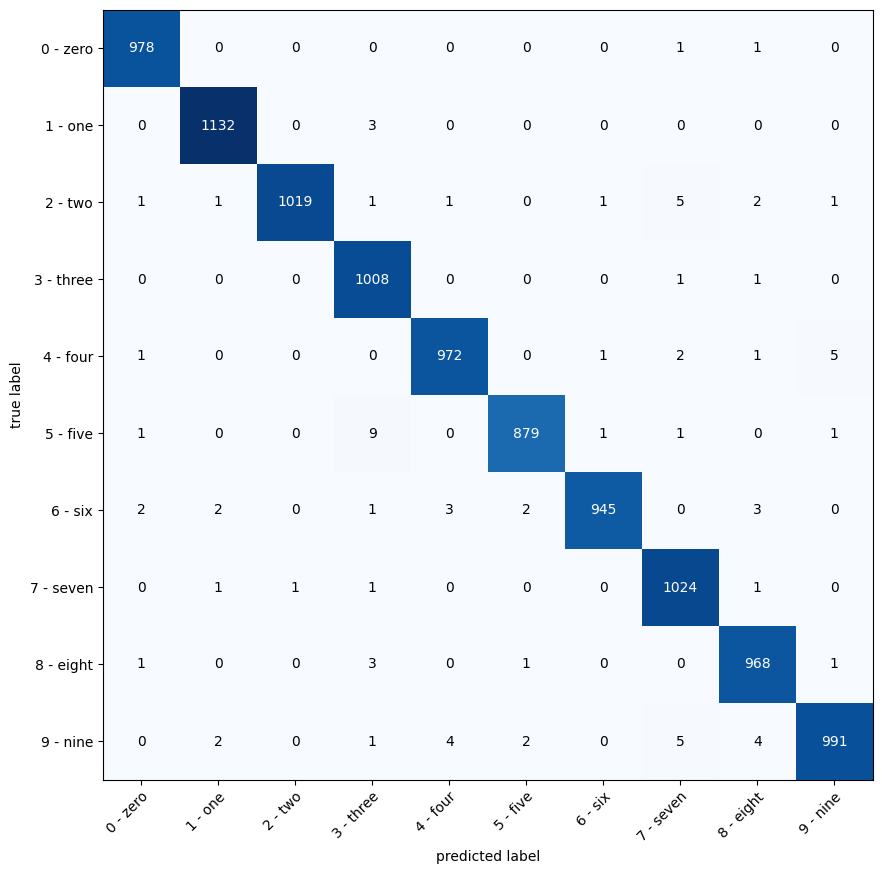

In [20]:
# Plot a confusion matrix comparing the true labels and the predicted labels using torchmetrics
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix
label_preds = label_preds.cpu()
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds = label_preds,
                        target = test_data.targets)

# Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10, 10)
)


## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [21]:
# set random seed = 42
torch.manual_seed(42)
# create a random tensor of shape [1, 3, 64, 64]
tensor_01 = torch.randn(1, 3, 64, 64)
# pass it through nn.Conv2d with in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1
conv_layer_01 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3, stride=1, padding=1)
output_01 = conv_layer_01(tensor_01)
output_01.shape

torch.Size([1, 8, 64, 64])

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset. 
* Then plot some predictions where the model was wrong alongside what the label of the image should've been. 
* After visualing these predictions do you think it's more of a modelling error or a data error? 
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [6]:
# load V2 model
model_3_3 = FashionMNISTModel_2()
model_3_3

FashionMNISTModel_2(
  (block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (block_2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block_3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
  )
  (block_4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=10, bias=True)
  )
)

In [9]:
# load FashionMNIST train data
from torchvision import datasets
from torchvision import transforms
data_root = "D:/VScodeProjects/pytorch-deep-learning/data"
train_data = datasets.FashionMNIST(root=data_root,
                                   train=True,
                                   download=False,
                                   transform=transforms.ToTensor())
# load FashionMNIST test data
test_data = datasets.FashionMNIST(root=data_root,
                                  train=False,
                                  download=False,
                                  transform=transforms.ToTensor())

len(train_data), len(test_data)

(60000, 10000)

In [ ]:
# Show the data structure of data
# It seems like a data is composed of a tensor and an int
print(type(train_data[0]))
print(len(train_data[0]))
type(train_data[0][0]), type(train_data[0][1])

<class 'tuple'>
2


(torch.Tensor, int)

In [10]:
fashion_class_names = train_data.classes
fashion_class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [13]:
from torch.utils.data import DataLoader
# create dataloader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

len(train_loader), len(test_loader)

(1875, 313)

In [18]:
# setup metrics
import torch.optim as optim
from tqdm.auto import tqdm
from torchmetrics import Accuracy

acc_fn = Accuracy(task = 'multiclass', num_classes = len(fashion_class_names)).to(device)
# build train loop on GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_3_3.to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_3_3.parameters(), lr=0.01)

def train_loop(model, train_loader, loss_fn, optimizer, device):
    epochs = 5
    # training
    model.train()
    for epoch in tqdm(range(epochs)):
        train_loss, test_loss_total = 0, 0
        train_acc, test_acc = 0, 0
        for batch, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            # optimizer.zero_grad()
            # forward pass
            label_pred = model(images)
            
            loss = loss_fn(label_pred, labels)
            train_loss += loss
            train_acc += acc_fn(label_pred, labels)
            # back propagation
            optimizer.zero_grad()  # zero gradients
            loss.backward()  # calculate gradients
            optimizer.step()  # update weights
    
        train_loss = train_loss / len(train_loader)
        train_acc = train_acc / len(train_loader)
        # testing
        model.eval()
        test_loss = 0  # Initialize test_loss
        with torch.inference_mode():
            for batch, (test_images, test_labels) in enumerate(test_loader):
                test_images, test_labels = test_images.to(device), test_labels.to(device)
                # forward pass
                label_pred = model(test_images)
                # calculate loss
                loss = loss_fn(label_pred, test_labels)
                test_loss_total += loss
                test_acc += acc_fn(label_pred, test_labels)
            # adjust the loss/acc
            test_loss = test_loss_total / len(test_loader)
            test_acc = test_acc / len(test_loader)

        print(f"Epoch: {epoch} |Train loss: {train_loss:.3f} | Test loss: {test_loss:.2f} | Test accuracy: {test_acc:.2f}")

train_loop(model_3_3, train_loader, loss_fn, optimizer, device)

 20%|██        | 1/5 [00:18<01:13, 18.50s/it]

Epoch: 0 |Train loss: 0.244 | Test loss: 0.29 | Test accuracy: 0.90


 40%|████      | 2/5 [00:36<00:53, 17.96s/it]

Epoch: 1 |Train loss: 0.237 | Test loss: 0.27 | Test accuracy: 0.90


 60%|██████    | 3/5 [00:55<00:37, 18.50s/it]

Epoch: 2 |Train loss: 0.230 | Test loss: 0.30 | Test accuracy: 0.89


 80%|████████  | 4/5 [01:14<00:18, 18.69s/it]

Epoch: 3 |Train loss: 0.222 | Test loss: 0.26 | Test accuracy: 0.91


100%|██████████| 5/5 [01:32<00:00, 18.49s/it]

Epoch: 4 |Train loss: 0.216 | Test loss: 0.26 | Test accuracy: 0.91


In [19]:
# Make predictions with model_3_3
test_preds = []
model_3_3.eval()
with torch.inference_mode():
    for image_test, label_test in tqdm(test_loader):
        label_logits = model_3_3(image_test.to(device))
        label_probs = torch.softmax(label_logits, dim=1)
        label_preds = torch.argmax(label_probs, dim=1)
        test_preds.append(label_preds)
test_preds = torch.cat(test_preds).cpu()
test_preds[:10], len(test_preds)

100%|██████████| 313/313 [00:01<00:00, 220.36it/s]


(tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7]), 10000)

In [20]:
# Count wrong prediction numbers
import numpy as np
wrong_anwers = np.where(test_preds != test_data.targets)[0]
print(f"Wrong answers / All answerrs = {len(wrong_anwers)} / {len(test_data)}")

Wrong answers / All answerrs = 937 / 10000


In [24]:
wrong_anwers[:10]

array([12, 23, 25, 40, 42, 48, 49, 67, 68, 89], dtype=int64)

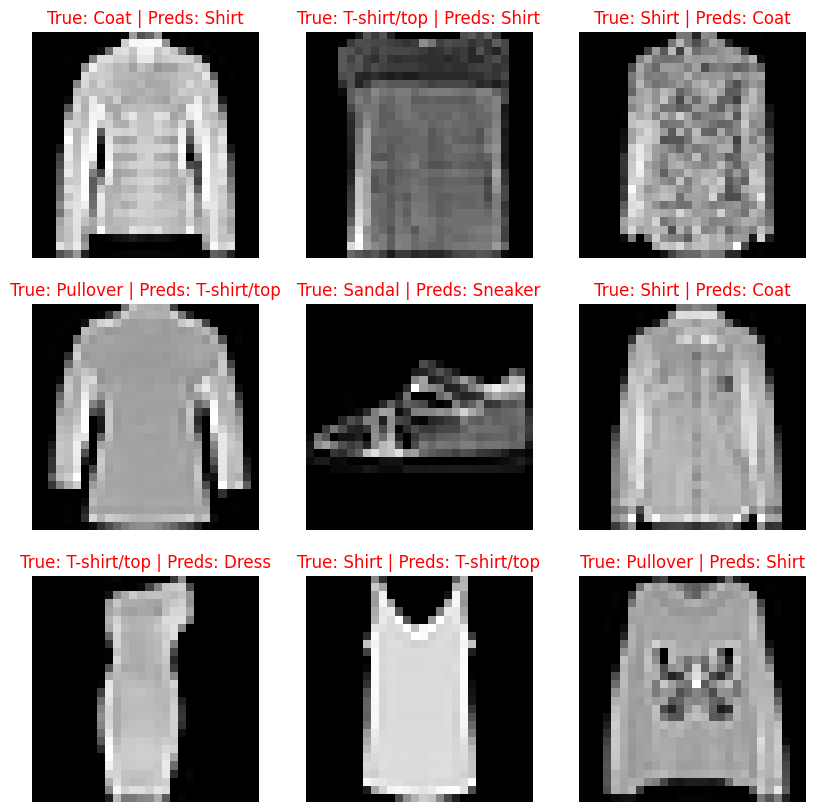

In [23]:
# Visualize 9 wrong predictions
import random
import matplotlib.pyplot as plt
random_wrong_answers = random.sample(list(wrong_anwers), k=9)

plt.figure(figsize=(10, 10))
for i, idx in enumerate(random_wrong_answers):
    true_label = train_data.classes[test_data[idx][1]]
    pred_label = train_data.classes[test_preds[idx]]

    plt.subplot(3, 3, i + 1)
    plt.imshow(test_data[idx][0].squeeze(), cmap="gray")
    plt.title(f"True: {true_label} | Preds: {pred_label}", c="r")
    plt.axis(False)